In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import data
train = pd.read_parquet('../data/model/final_train.parquet')
val = pd.read_parquet('../data/model/final_val.parquet')
test = pd.read_parquet('../data/model/final_test.parquet')

In [3]:
# check the min and max Date in each dataset
print("Train Date range:", train['Date'].min(), "to", train['Date'].max())
print("Validation Date range:", val['Date'].min(), "to", val['Date'].max())
print("Test Date range:", test['Date'].min(), "to", test['Date'].max())

Train Date range: 2016-01-04 00:00:00 to 2021-12-30 00:00:00
Validation Date range: 2022-01-03 00:00:00 to 2022-12-30 00:00:00
Test Date range: 2023-01-03 00:00:00 to 2023-12-29 00:00:00


In [4]:
X_train = train.loc[:, train.columns != "return_next_day"]
X_val = val.loc[:, val.columns != "return_next_day"]
X_test = test.loc[:, test.columns != "return_next_day"]
X_full = pd.concat([X_train, X_val, X_test], axis=0).reset_index(drop=True)
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

In [5]:
y_train = train[['Date', 'tic', 'return_next_day']]
y_val = val[['Date', 'tic', 'return_next_day']]
y_test = test[['Date', 'tic', 'return_next_day']]
y_full = pd.concat([y_train, y_val, y_test], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [6]:
X_train.head()

,Date,tic,Open,High,Low,Close,Volume,sales_growth_qoq,sales_growth_ttm,asset_growth,...,pca_emb_54,pca_emb_55,pca_emb_56,pca_emb_57,pca_emb_58,pca_emb_59,pca_emb_60,pca_emb_61,pca_emb_62,pca_emb_63
0,2016-01-04,A,37.978592,38.098833,37.312624,37.636356,3287300,0.02071,-0.00247,-0.309482,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2016-01-05,A,37.673370,37.876861,37.312638,37.506878,2587200,0.02071,-0.00247,-0.309482,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2016-01-06,A,37.220145,37.913860,37.044401,37.673370,2103600,0.02071,-0.00247,-0.309482,...,0.142439,-0.088256,0.401539,0.468688,0.084403,-0.750782,-0.323059,0.027356,-0.609138,-0.380578
3,2016-01-07,A,37.127663,37.136914,35.897475,36.073215,3504300,0.02071,-0.00247,-0.309482,...,-0.344860,-0.048228,0.058563,0.191014,0.074542,-0.062964,-0.121446,0.122892,-0.254481,0.042727
4,2016-01-08,A,36.276692,36.729917,35.582976,35.693970,3736700,0.02071,-0.00247,-0.309482,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
y_train.head()

,Date,tic,return_next_day
0,2016-01-04,A,-0.003440
1,2016-01-05,A,0.004439
2,2016-01-06,A,-0.042474
3,2016-01-07,A,-0.010513
4,2016-01-08,A,-0.016844


#### Baseline 0 - predict return as yesterday's return

In [6]:
def make_persistence_pred(
    df,
    full_df=None,
    ticker_col="tic",
    date_col="Date",
    price_col="Close",
    prediction_col="prediction",
):
    """
    Build a persistence-model prediction DataFrame:
    prediction(t) = realized return(t-1) for the same ticker.

    If full_df is provided (e.g., X_full with train+val+test), then
    previous-day returns are computed on full_df so that boundaries
    between splits are handled correctly.

    Returns a DataFrame with [date_col, ticker_col, prediction_col].
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Case 1: use ONLY df (original behavior)
    if full_df is None:
        df = df.sort_values([ticker_col, date_col])

        prev_col = "_prev_close_tmp"
        df[prev_col] = df.groupby(ticker_col)[price_col].shift(1)

        ret = (df[price_col] - df[prev_col]) / df[prev_col]
        prediction = ret.groupby(df[ticker_col]).shift(1)

        pred_df = pd.DataFrame({
            date_col: df[date_col],
            ticker_col: df[ticker_col],
            prediction_col: prediction.fillna(0),
        })

        pred_df = pred_df.sort_values([ticker_col, date_col]).reset_index(drop=True)
        return pred_df

    # Case 2: use full_df (X_full) to get cross-split prev-day info
    full = full_df.copy()
    full[date_col] = pd.to_datetime(full[date_col])
    full = full.sort_values([ticker_col, date_col])

    prev_col = "_prev_close_tmp"
    full[prev_col] = full.groupby(ticker_col)[price_col].shift(1)

    # realized return on full data
    full["_ret_tmp"] = (full[price_col] - full[prev_col]) / full[prev_col]

    # prediction = previous day's return on full data
    full["_pred_tmp"] = full.groupby(ticker_col)["_ret_tmp"].shift(1)

    # now merge predictions for just the rows in df
    pred_df = df[[date_col, ticker_col]].merge(
        full[[date_col, ticker_col, "_pred_tmp"]],
        on=[date_col, ticker_col],
        how="left",
    )

    pred_df = pred_df.rename(columns={"_pred_tmp": prediction_col})
    pred_df[prediction_col] = pred_df[prediction_col].fillna(0)

    pred_df = pred_df.sort_values([ticker_col, date_col]).reset_index(drop=True)
    return pred_df

In [7]:
trainval_pred_b0 = make_persistence_pred(X_trainval, X_full)
test_pred_b0  = make_persistence_pred(X_test, X_full)

In [8]:
test_pred_b0.head()

,Date,tic,prediction
0,2023-01-03,A,-0.008054
1,2023-01-04,A,0.002606
2,2023-01-05,A,0.010864
3,2023-01-06,A,0.002901
4,2023-01-09,A,-0.029189


In [9]:
def _merge_pred_true(
    pred_df,
    y_df,
    on_cols=("Date", "tic"),
    pred_col="prediction",
    actual_col="ret",
):
    """
    Merge prediction and ground-truth dataframes on key columns.
    Returns a DataFrame with columns: on_cols + [pred_col, actual_col].
    """
    merged = (
        pred_df[list(on_cols) + [pred_col]]
        .merge(
            y_df[list(on_cols) + [actual_col]],
            on=list(on_cols),
            how="inner",
        )
    )
    return merged


def total_accuracy(pred_df, y_df,
                   on_cols=("Date", "tic"),
                   pred_col="prediction",
                   actual_col="return_next_day"):
    """
    Overall directional accuracy:
    sign(prediction) == sign(actual)
    """
    df = _merge_pred_true(pred_df, y_df, on_cols, pred_col, actual_col)
    correct = np.sign(df[pred_col]) == np.sign(df[actual_col])
    return correct.mean()


def accuracy_by_ticker(pred_df, y_df,
                       ticker_col="tic",
                       on_cols=("Date", "tic"),
                       pred_col="prediction",
                       actual_col="return_next_day"):
    """
    Directional accuracy grouped by ticker.
    Returns a Series indexed by ticker.
    """
    df = _merge_pred_true(pred_df, y_df, on_cols, pred_col, actual_col)
    correct = np.sign(df[pred_col]) == np.sign(df[actual_col])
    return correct.groupby(df[ticker_col]).mean()


def accuracy_by_month(pred_df, y_df,
                      date_col="Date",
                      on_cols=("Date", "tic"),
                      pred_col="prediction",
                      actual_col="return_next_day"):
    """
    Directional accuracy grouped by calendar month (year-month).
    E.g., 2021-01 and 2022-01 are different groups.
    
    Returns a Series indexed by Period('YYYY-MM', 'M').
    """
    df = _merge_pred_true(pred_df, y_df, on_cols, pred_col, actual_col)
    
    dates = pd.to_datetime(df[date_col])
    months = dates.dt.to_period("M")   # year-month, e.g. 2021-01, 2022-01
    
    correct = np.sign(df[pred_col]) == np.sign(df[actual_col])
    return correct.groupby(months).mean()

In [10]:
# train
trainval_acc_total_b0  = total_accuracy(trainval_pred_b0, y_trainval)
trainval_acc_ticker_b0 = accuracy_by_ticker(trainval_pred_b0, y_trainval)
trainval_acc_month_b0   = accuracy_by_month(trainval_pred_b0, y_trainval)

# test
test_acc_total_b0  = total_accuracy(test_pred_b0, y_test)
test_acc_ticker_b0 = accuracy_by_ticker(test_pred_b0, y_test)
test_acc_month_b0   = accuracy_by_month(test_pred_b0, y_test)

In [11]:
trainval_acc_total_b0

np.float64(0.49599370790935454)

In [12]:
trainval_acc_ticker_b0.sort_values(ascending=False)

tic
AMCR    0.582480
MKTX    0.533561
TPL     0.529579
GS      0.529010
JPM     0.526166
          ...   
F       0.462457
MO      0.461889
SMCI    0.453925
NWS     0.451650
GEHC    0.363636
Length: 498, dtype: float64

In [13]:
trainval_acc_month_b0.sort_values(ascending=False)

Date
2020-03    0.573961
2016-05    0.567283
2018-06    0.548065
2021-01    0.529832
2016-07    0.527174
             ...   
2020-11    0.451423
2019-10    0.447408
2018-02    0.439803
2016-02    0.435138
2022-02    0.417346
Freq: M, Length: 84, dtype: float64

In [16]:
test_acc_total_b0

np.float64(0.4870958172649066)

In [17]:
test_acc_ticker_b0.sort_values(ascending=False)

tic
BRO     0.568000
RCL     0.568000
VZ      0.568000
MCO     0.568000
IT      0.564000
          ...   
VLTO    0.409836
JBHT    0.408000
SW      0.408000
WRB     0.404000
AMCR    0.388000
Length: 500, dtype: float64

In [18]:
test_acc_month_b0.sort_values(ascending=False)

Date
2023-11    0.521905
2023-08    0.515379
2023-09    0.504810
2023-03    0.495809
2023-02    0.488163
2023-10    0.481269
2023-07    0.480461
2023-04    0.477806
2023-06    0.472278
2023-12    0.472100
2023-01    0.466767
2023-05    0.464237
Freq: M, dtype: float64

#### Baseline 1 - predict return based on moving average

In [16]:
def make_ma_return_pred(
    df,
    full_df=None,
    window=5,
    ticker_col="tic",
    date_col="Date",
    price_col="Close",
    prediction_col="prediction",
):
    """
    Build a moving-average return prediction DataFrame.

    prediction(t) = moving average of past `window` returns
                    for the same ticker, using ONLY information
                    strictly before time t (no look-ahead).

    If full_df is provided (e.g., X_full with train+val+test),
    returns are computed on full_df so that cross-split history
    is used. Otherwise, only df is used.

    Returns a DataFrame with [date_col, ticker_col, prediction_col].
    """
    # -------- helper to compute predictions on a given base DataFrame --------
    def _compute_on_base(base):
        base = base.copy()
        base[date_col] = pd.to_datetime(base[date_col])
        base = base.sort_values([ticker_col, date_col])

        # daily returns per ticker
        base["_ret_tmp"] = base.groupby(ticker_col)[price_col].pct_change()

        # rolling mean of returns (includes current day's return)
        base["_ma_ret_tmp"] = base.groupby(ticker_col)["_ret_tmp"].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )

        # prediction at time t = MA of past `window` returns *before* t
        base["_pred_tmp"] = base.groupby(ticker_col)["_ma_ret_tmp"].shift(1)

        return base

    # ----------------- Case 1: only use df (no full_df) -----------------
    if full_df is None:
        base = _compute_on_base(df)

        pred_df = base[[date_col, ticker_col, "_pred_tmp"]].rename(
            columns={"_pred_tmp": prediction_col}
        )
        pred_df[prediction_col] = pred_df[prediction_col].fillna(0)

        pred_df = pred_df.sort_values([ticker_col, date_col]).reset_index(drop=True)
        return pred_df

    # ----------------- Case 2: use full_df for history -----------------
    # compute MA-based prediction on full data
    full = _compute_on_base(full_df)

    # now pick out predictions for just the rows in df
    df_local = df.copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])

    pred_df = df_local[[date_col, ticker_col]].merge(
        full[[date_col, ticker_col, "_pred_tmp"]],
        on=[date_col, ticker_col],
        how="left",
    )

    pred_df = pred_df.rename(columns={"_pred_tmp": prediction_col})
    pred_df[prediction_col] = pred_df[prediction_col].fillna(0)

    pred_df = pred_df.sort_values([ticker_col, date_col]).reset_index(drop=True)
    return pred_df

In [17]:
# mapping from label -> window size (in trading days)
ma_windows = {
    "2d": 2,
    "3d": 3,
    "4d": 4,
    "1w": 5,    # 1 week ≈ 5 trading days
    "2w": 10,   # 2 weeks ≈ 10 trading days
    "1m": 21,   # 1 month ≈ 21 trading days
    "7d": 7,
    "14d": 14,
    "30d": 30,
    "50d": 50,
}

trainval_ma_preds = {}
test_ma_preds  = {}

for label, w in ma_windows.items():
    trainval_ma_preds[label] = make_ma_return_pred(X_trainval, full_df=X_full, window=w)
    test_ma_preds[label]  = make_ma_return_pred(X_test,  full_df=X_full, window=w)

In [18]:
# dictionaries to store results
trainval_acc_total_ma = {}
test_acc_total_ma     = {}

trainval_acc_ticker_ma = {}
test_acc_ticker_ma     = {}

trainval_acc_month_ma = {}
test_acc_month_ma     = {}

for label in trainval_ma_preds.keys():
    # ----- train+val -----
    trainval_pred = trainval_ma_preds[label]
    trainval_acc_total_ma[label]  = total_accuracy(trainval_pred, y_trainval)
    trainval_acc_ticker_ma[label] = accuracy_by_ticker(trainval_pred, y_trainval)
    trainval_acc_month_ma[label]  = accuracy_by_month(trainval_pred, y_trainval)

    # ----- test -----
    test_pred = test_ma_preds[label]
    test_acc_total_ma[label]  = total_accuracy(test_pred, y_test)
    test_acc_ticker_ma[label] = accuracy_by_ticker(test_pred, y_test)
    test_acc_month_ma[label]  = accuracy_by_month(test_pred, y_test)

In [19]:
acc_summary = pd.DataFrame({
    "window": list(trainval_ma_preds.keys()),
    "trainval_total_acc": [trainval_acc_total_ma[w] for w in trainval_ma_preds.keys()],
    "test_total_acc":  [test_acc_total_ma[w]  for w in trainval_ma_preds.keys()],
})

print(acc_summary.sort_values("trainval_total_acc", ascending=False))

  window  trainval_total_acc  test_total_acc
9    50d            0.502006        0.497815
5     1m            0.501948        0.501728
8    30d            0.500434        0.496308
4     2w            0.499397        0.498505
7    14d            0.499307        0.500132
0     2d            0.496958        0.495210
2     4d            0.496867        0.489261
6     7d            0.496512        0.498513
3     1w            0.496510        0.492700
1     3d            0.495667        0.490519


In [53]:
# Find best MA window
best_ma_window = acc_summary.iloc[0]["window"]

# Create one clean row
best_ma_row = pd.DataFrame({
    "model_name": [f"ma_{best_ma_window}"],
    "trainval_accuracy": [acc_summary.iloc[0]["trainval_total_acc"]],
    "test_accuracy": [acc_summary.iloc[0]["test_total_acc"]]
})

# Append to comparison df
model_comparison_df = pd.concat([model_comparison_df, best_ma_row], ignore_index=True)

model_comparison_df

,model_name,trainval_accuracy,test_accuracy
0,yesterday_return,0.495994,0.487096
1,ma_2d,0.496958,0.495210


In [54]:
# 1) Build accuracy matrix: rows = tickers, cols = MA windows
acc_matrix = pd.DataFrame(trainval_acc_ticker_ma)
# index = tickers, columns = ["2d", "3d", "4d", "1w", "2w", "1m"]

# 2) For each ticker, select the MA window with highest trainval accuracy
best_window_per_tic = acc_matrix.idxmax(axis=1)


# ================================
# === HYBRID PRED FOR TRAINVAL ===
# ================================

trainval_base = y_trainval[["Date", "tic"]].copy()

for label, pred_df in trainval_ma_preds.items():
    trainval_base = trainval_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{label}"}),
        on=["Date", "tic"],
        how="left",
    )

trainval_base["best_window"] = trainval_base["tic"].map(best_window_per_tic)

def pick_pred(row):
    lbl = row["best_window"]
    if pd.isna(lbl):
        return np.nan
    return row[f"pred_{lbl}"]

trainval_base["prediction"] = trainval_base.apply(pick_pred, axis=1)
trainval_hybrid_ma_pred = trainval_base[["Date", "tic", "prediction"]]


# ================================
# ==== HYBRID PRED FOR TEST ======
# ================================

test_base = y_test[["Date", "tic"]].copy()

for label, pred_df in test_ma_preds.items():
    test_base = test_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{label}"}),
        on=["Date", "tic"],
        how="left",
    )

test_base["best_window"] = test_base["tic"].map(best_window_per_tic)
test_base["prediction"] = test_base.apply(pick_pred, axis=1)
test_hybrid_ma_pred = test_base[["Date", "tic", "prediction"]]


# ================================
# ===== ACCURACY RESULTS =========
# ================================

trainval_acc_total_hybrid = total_accuracy(trainval_hybrid_ma_pred, y_trainval)
test_acc_total_hybrid     = total_accuracy(test_hybrid_ma_pred, y_test)

print("Hybrid Train+Val Total Accuracy:", trainval_acc_total_hybrid)
print("Hybrid Test Total Accuracy:     ", test_acc_total_hybrid)

Hybrid Train+Val Total Accuracy: 0.513216199324443
Hybrid Test Total Accuracy:      0.496700794535265


In [26]:
acc_df = pd.DataFrame({
    "window": list(ma_windows.keys()),
    "trainval_acc": [trainval_acc_total_ma[w] for w in ma_windows.keys()],
    "test_acc":     [test_acc_total_ma[w]     for w in ma_windows.keys()],
})

acc_df.sort_values("trainval_acc", ascending=False)

,window,trainval_acc,test_acc
9,50d,0.502006,0.497815
5,1m,0.501948,0.501728
8,30d,0.500434,0.496308
4,2w,0.499397,0.498505
7,14d,0.499307,0.500132
0,2d,0.496958,0.495210
2,4d,0.496867,0.489261
6,7d,0.496512,0.498513
3,1w,0.496510,0.492700
1,3d,0.495667,0.490519


In [25]:
test_base

,Date,tic,pred_2d,pred_3d,pred_4d,pred_1w,pred_2w,pred_1m,pred_7d,pred_14d,pred_30d,pred_50d,best_window,prediction
0,2023-01-03,A,0.006102,0.000814,0.001147,0.001213,-0.000594,-0.001496,0.001924,-0.001355,0.000831,0.003239,2d,0.006102
1,2023-01-04,A,-0.002724,0.004937,0.001262,0.001438,0.000700,-0.001722,0.000210,-0.002281,0.001525,0.003759,2d,-0.002724
2,2023-01-05,A,0.006735,0.001805,0.006419,0.003182,0.003361,-0.001068,0.002790,-0.002576,0.001483,0.003351,2d,0.006735
3,2023-01-06,A,0.006882,0.005457,0.002079,0.005715,0.002984,-0.000021,0.002994,-0.001078,0.001820,0.003036,2d,0.006882
4,2023-01-09,A,-0.013144,-0.005141,-0.003205,-0.004174,-0.001395,-0.000990,-0.001482,-0.001340,-0.001845,0.002120,2d,-0.013144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124722,2023-12-22,ZTS,-0.008632,-0.003450,-0.002040,-0.005430,0.006962,0.004160,0.002493,0.006064,0.004431,0.002099,30d,0.004431
124723,2023-12-26,ZTS,0.000899,-0.005206,-0.002176,-0.001303,0.005603,0.004073,-0.001704,0.004989,0.004533,0.002431,30d,0.004533
124724,2023-12-27,ZTS,0.002155,0.001488,-0.003238,-0.001208,0.003237,0.003972,-0.003263,0.006148,0.004878,0.002476,30d,0.004878
124725,2023-12-28,ZTS,0.004914,0.003824,0.002907,-0.001158,0.002892,0.004688,0.000473,0.005725,0.005213,0.002527,30d,0.005213


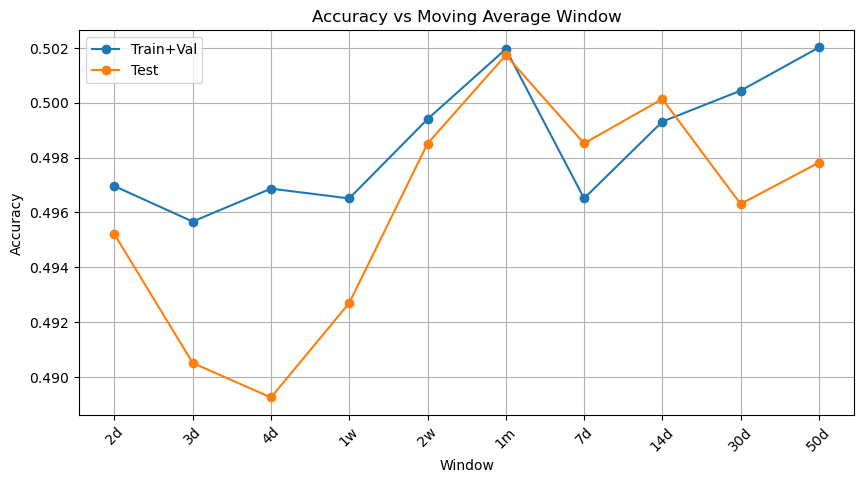

In [55]:
plt.figure(figsize=(10,5))
plt.plot(acc_df["window"], acc_df["trainval_acc"], marker='o', label="Train+Val")
plt.plot(acc_df["window"], acc_df["test_acc"],     marker='o', label="Test")
plt.title("Accuracy vs Moving Average Window")
plt.ylabel("Accuracy")
plt.xlabel("Window")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

#### Baseline 2 - hybrid model using baseline 1 (predict yesterday's) and 2 (moving average)

In [56]:
# Baseline 0 accuracy per ticker on train+val
trainval_acc_ticker_b0 = accuracy_by_ticker(trainval_pred_b0, y_trainval)

# MA hybrid accuracy per ticker on train+val
trainval_acc_ticker_mahybrid = accuracy_by_ticker(trainval_hybrid_ma_pred, y_trainval)

In [57]:
# Baseline 0 accuracy per ticker on train+val
test_acc_ticker_b0 = accuracy_by_ticker(test_pred_b0, y_test)

# MA hybrid accuracy per ticker on train+val
test_acc_ticker_mahybrid = accuracy_by_ticker(test_hybrid_ma_pred, y_test)

In [58]:
acc_compare = pd.DataFrame({
    "b0": trainval_acc_ticker_b0,
    "ma": trainval_acc_ticker_mahybrid,
})

In [59]:
best_model_per_tic = acc_compare.idxmax(axis=1)  # values: "b0" or "ma"

In [60]:
# wide table with both models' predictions for train+val
trainval_b2_base = y_trainval[["Date", "tic"]].copy()

trainval_b2_base = trainval_b2_base.merge(
    trainval_pred_b0[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_b0"}),
    on=["Date", "tic"],
    how="left",
)

trainval_b2_base = trainval_b2_base.merge(
    trainval_hybrid_ma_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ma"}),
    on=["Date", "tic"],
    how="left",
)

# map ticker -> which model to use ("b0" or "ma")
trainval_b2_base["best_model"] = trainval_b2_base["tic"].map(best_model_per_tic)

def pick_b2_pred(row):
    if row["best_model"] == "ma":
        return row["pred_ma"]
    else:
        return row["pred_b0"]

trainval_b2_base["prediction"] = trainval_b2_base.apply(pick_b2_pred, axis=1)

# final Baseline 2 predictions for train+val
trainval_pred_b2 = trainval_b2_base[["Date", "tic", "prediction"]]

In [61]:
test_b2_base = y_test[["Date", "tic"]].copy()

test_b2_base = test_b2_base.merge(
    test_pred_b0[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_b0"}),
    on=["Date", "tic"],
    how="left",
)

test_b2_base = test_b2_base.merge(
    test_hybrid_ma_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ma"}),
    on=["Date", "tic"],
    how="left",
)

# use the SAME best_model_per_tic learned on train+val
test_b2_base["best_model"] = test_b2_base["tic"].map(best_model_per_tic)

test_b2_base["prediction"] = test_b2_base.apply(pick_b2_pred, axis=1)

# final Baseline 2 predictions for test
test_pred_b2 = test_b2_base[["Date", "tic", "prediction"]]

In [62]:
# Train+Val
trainval_acc_total_b2  = total_accuracy(trainval_pred_b2, y_trainval)
trainval_acc_ticker_b2 = accuracy_by_ticker(trainval_pred_b2, y_trainval)
trainval_acc_month_b2  = accuracy_by_month(trainval_pred_b2, y_trainval)

# Test
test_acc_total_b2  = total_accuracy(test_pred_b2, y_test)
test_acc_ticker_b2 = accuracy_by_ticker(test_pred_b2, y_test)
test_acc_month_b2  = accuracy_by_month(test_pred_b2, y_test)

print("Baseline 2 (B2) Train+Val Total Accuracy:", trainval_acc_total_b2)
print("Baseline 2 (B2) Test Total Accuracy:     ", test_acc_total_b2)

Baseline 2 (B2) Train+Val Total Accuracy: 0.5138201276676427
Baseline 2 (B2) Test Total Accuracy:      0.49750254555950196


In [64]:
# -----------------------------------------
# Build summary rows for all models so far
# -----------------------------------------

rows = []

# ---- Baseline 0 ----
rows.append({
    "model": "baseline_0",
    "trainval_acc": trainval_acc_total_b0,
    "test_acc":     test_acc_total_b0
})

# ---- All MA window models ----
for label in ma_windows.keys():  # e.g., "2d", "3d", ...
    rows.append({
        "model": f"ma_{label}",
        "trainval_acc": trainval_acc_total_ma[label],
        "test_acc":     test_acc_total_ma[label]
    })

# ---- MA hybrid (best MA per ticker) ----
rows.append({
    "model": "ma_hybrid_best_per_ticker",
    "trainval_acc": trainval_acc_total_hybrid,
    "test_acc":     test_acc_total_hybrid
})

# ---- Baseline 2 (best of baseline0 vs MA hybrid per ticker) ----
rows.append({
    "model": "baseline_2",
    "trainval_acc": trainval_acc_total_b2,
    "test_acc":     test_acc_total_b2
})

# ---- Create DataFrame ----
model_comparison_df = pd.DataFrame(rows)

# Sort by test accuracy (descending)
model_comparison_df = model_comparison_df.sort_values("trainval_acc", ascending=False).reset_index(drop=True)

model_comparison_df

,model,trainval_acc,test_acc
0,baseline_2,0.513820,0.497503
1,ma_hybrid_best_per_ticker,0.513216,0.496701
2,ma_50d,0.502006,0.497815
3,ma_1m,0.501948,0.501728
4,ma_30d,0.500434,0.496308
5,ma_2w,0.499397,0.498505
6,ma_14d,0.499307,0.500132
7,ma_2d,0.496958,0.495210
8,ma_4d,0.496867,0.489261
9,ma_7d,0.496512,0.498513


In [66]:
# rename baseline_0 to yesterday, baseline_2 to yesterday_and_ma
model_comparison_df = model_comparison_df.replace({
    "model": {
        "baseline_0": "yesterday",
        "baseline_2": "yesterday_and_ma"
    }
})
model_comparison_df

,model,trainval_acc,test_acc
0,yesterday_and_ma,0.513820,0.497503
1,ma_hybrid_best_per_ticker,0.513216,0.496701
2,ma_50d,0.502006,0.497815
3,ma_1m,0.501948,0.501728
4,ma_30d,0.500434,0.496308
5,ma_2w,0.499397,0.498505
6,ma_14d,0.499307,0.500132
7,ma_2d,0.496958,0.495210
8,ma_4d,0.496867,0.489261
9,ma_7d,0.496512,0.498513


#### Baseline 3 - Exponential Moving Average (EMA) Predictions

In [67]:
def make_ema_return_pred(
    df,
    full_df=None,
    span=5,     # span ≈ window
    ticker_col="tic",
    date_col="Date",
    price_col="Close",
    prediction_col="prediction",
):
    def _compute_on_base(base):
        base = base.copy()
        base[date_col] = pd.to_datetime(base[date_col])
        base = base.sort_values([ticker_col, date_col])

        base["_ret"] = base.groupby(ticker_col)[price_col].pct_change()

        base["_ema_ret"] = base.groupby(ticker_col)["_ret"].transform(
            lambda x: x.ewm(span=span, adjust=False).mean()
        )

        base["_pred"] = base.groupby(ticker_col)["_ema_ret"].shift(1)
        return base

    if full_df is None:
        base = _compute_on_base(df)
        pred = base[[date_col, ticker_col, "_pred"]].rename(columns={"_pred": prediction_col})
        pred[prediction_col] = pred[prediction_col].fillna(0)
        return pred

    full = _compute_on_base(full_df)

    df_local = df[[date_col, ticker_col]].copy()
    pred = df_local.merge(
        full[[date_col, ticker_col, "_pred"]],
        on=[date_col, ticker_col],
        how="left"
    )
    pred = pred.rename(columns={"_pred": prediction_col})
    pred[prediction_col] = pred[prediction_col].fillna(0)
    return pred

In [68]:
ema_spans = {
    "ema_5": 5,
    "ema_10": 10,
    "ema_20": 20,
    "ema_50": 50,
}

trainval_ema_preds = {}
test_ema_preds     = {}

for label, span in ema_spans.items():
    trainval_ema_preds[label] = make_ema_return_pred(X_trainval, full_df=X_full, span=span)
    test_ema_preds[label]     = make_ema_return_pred(X_test,     full_df=X_full, span=span)

In [69]:
# trainval + test accuracy for each EMA span
ema_trainval_acc = {
    label: total_accuracy(trainval_ema_preds[label], y_trainval)
    for label in ema_spans.keys()
}

ema_test_acc = {
    label: total_accuracy(test_ema_preds[label], y_test)
    for label in ema_spans.keys()
}

ema_acc_df = pd.DataFrame({
    "method": list(ema_spans.keys()),
    "trainval_acc": [ema_trainval_acc[label] for label in ema_spans.keys()],
    "test_acc":     [ema_test_acc[label]     for label in ema_spans.keys()],
})

ema_acc_df.sort_values("trainval_acc", ascending=False)

,method,trainval_acc,test_acc
3,ema_50,0.503789,0.499154
2,ema_20,0.500320,0.498216
1,ema_10,0.498082,0.497214
0,ema_5,0.497148,0.492732


In [70]:
# per-ticker accuracy for each EMA span on train+val
trainval_acc_ticker_ema = {
    label: accuracy_by_ticker(trainval_ema_preds[label], y_trainval)
    for label in ema_spans.keys()
}

# build accuracy matrix: rows = tickers, cols = EMA labels ("ema_5", "ema_10", ...)
acc_matrix_ema = pd.DataFrame(trainval_acc_ticker_ema)  # index=tic, columns=ema labels

# for each ticker, pick the EMA label with highest train+val accuracy
best_ema_per_tic = acc_matrix_ema.idxmax(axis=1)  # Series: index=tic, value like "ema_5"

In [71]:
# base table with all EMA predictions for train+val
trainval_ema_hybrid_base = y_trainval[["Date", "tic"]].copy()

for label, pred_df in trainval_ema_preds.items():
    trainval_ema_hybrid_base = trainval_ema_hybrid_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{label}"}),
        on=["Date", "tic"],
        how="left",
    )

# map each ticker to its best EMA label
trainval_ema_hybrid_base["best_ema"] = trainval_ema_hybrid_base["tic"].map(best_ema_per_tic)

def pick_ema_hybrid_pred(row):
    lbl = row["best_ema"]
    if pd.isna(lbl):
        return np.nan
    return row[f"pred_{lbl}"]

trainval_ema_hybrid_base["prediction"] = trainval_ema_hybrid_base.apply(pick_ema_hybrid_pred, axis=1)

# final EMA-hybrid prediction DF for train+val
trainval_hybrid_ema_pred = trainval_ema_hybrid_base[["Date", "tic", "prediction"]]

In [72]:
test_ema_hybrid_base = y_test[["Date", "tic"]].copy()

for label, pred_df in test_ema_preds.items():
    test_ema_hybrid_base = test_ema_hybrid_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{label}"}),
        on=["Date", "tic"],
        how="left",
    )

# use the SAME best_ema_per_tic learned from train+val
test_ema_hybrid_base["best_ema"] = test_ema_hybrid_base["tic"].map(best_ema_per_tic)
test_ema_hybrid_base["prediction"] = test_ema_hybrid_base.apply(pick_ema_hybrid_pred, axis=1)

# final EMA-hybrid prediction DF for test
test_hybrid_ema_pred = test_ema_hybrid_base[["Date", "tic", "prediction"]]

In [73]:
# Train+Val
trainval_acc_total_ema_hybrid  = total_accuracy(trainval_hybrid_ema_pred, y_trainval)
trainval_acc_ticker_ema_hybrid = accuracy_by_ticker(trainval_hybrid_ema_pred, y_trainval)
trainval_acc_month_ema_hybrid  = accuracy_by_month(trainval_hybrid_ema_pred, y_trainval)

# Test
test_acc_total_ema_hybrid  = total_accuracy(test_hybrid_ema_pred, y_test)
test_acc_ticker_ema_hybrid = accuracy_by_ticker(test_hybrid_ema_pred, y_test)
test_acc_month_ema_hybrid  = accuracy_by_month(test_hybrid_ema_pred, y_test)

print("EMA Hybrid (best span per ticker) Train+Val Total Accuracy:", trainval_acc_total_ema_hybrid)
print("EMA Hybrid (best span per ticker) Test Total Accuracy:     ", test_acc_total_ema_hybrid)

EMA Hybrid (best span per ticker) Train+Val Total Accuracy: 0.507721153643584
EMA Hybrid (best span per ticker) Test Total Accuracy:      0.49691726731180896


In [75]:
# add ema hybrid to model_comparison_df using concat
ema_hybrid_row = pd.DataFrame({
    "model": ["ema_hybrid_best_per_ticker"],
    "trainval_acc": [trainval_acc_total_ema_hybrid],
    "test_acc":     [test_acc_total_ema_hybrid]
})
model_comparison_df = pd.concat([model_comparison_df, ema_hybrid_row], ignore_index=True)
model_comparison_df

,model,trainval_acc,test_acc
0,yesterday_and_ma,0.513820,0.497503
1,ma_hybrid_best_per_ticker,0.513216,0.496701
2,ma_50d,0.502006,0.497815
3,ma_1m,0.501948,0.501728
4,ma_30d,0.500434,0.496308
5,ma_2w,0.499397,0.498505
6,ma_14d,0.499307,0.500132
7,ma_2d,0.496958,0.495210
8,ma_4d,0.496867,0.489261
9,ma_7d,0.496512,0.498513


#### Baseline 4 - hybrid model between predicting yesterday's return, MA, and EMA 

In [76]:
# per-ticker accuracy for each model on train+val
acc_ticker_b0   = accuracy_by_ticker(trainval_pred_b0,        y_trainval)
acc_ticker_ma   = accuracy_by_ticker(trainval_hybrid_ma_pred, y_trainval)
acc_ticker_ema  = accuracy_by_ticker(trainval_hybrid_ema_pred, y_trainval)

acc_compare_all = pd.DataFrame({
    "b0":  acc_ticker_b0,
    "ma":  acc_ticker_ma,
    "ema": acc_ticker_ema,
})

# for each ticker, which model wins? ("b0", "ma", or "ema")
best_model_all_per_tic = acc_compare_all.idxmax(axis=1)

In [77]:
trainval_b4_base = y_trainval[["Date", "tic"]].copy()

# add B0 predictions
trainval_b4_base = trainval_b4_base.merge(
    trainval_pred_b0[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_b0"}),
    on=["Date", "tic"],
    how="left",
)

# add MA-hybrid predictions
trainval_b4_base = trainval_b4_base.merge(
    trainval_hybrid_ma_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ma"}),
    on=["Date", "tic"],
    how="left",
)

# add EMA-hybrid predictions
trainval_b4_base = trainval_b4_base.merge(
    trainval_hybrid_ema_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ema"}),
    on=["Date", "tic"],
    how="left",
)

# map ticker -> best model ("b0", "ma", or "ema")
trainval_b4_base["best_model"] = trainval_b4_base["tic"].map(best_model_all_per_tic)

def pick_b4_pred(row):
    if row["best_model"] == "ma":
        return row["pred_ma"]
    elif row["best_model"] == "ema":
        return row["pred_ema"]
    else:
        return row["pred_b0"]

trainval_b4_base["prediction"] = trainval_b4_base.apply(pick_b4_pred, axis=1)

# final Baseline 4 predictions for train+val
trainval_pred_b4 = trainval_b4_base[["Date", "tic", "prediction"]]

In [80]:
test_b4_base = y_test[["Date", "tic"]].copy()

# add B0 predictions
test_b4_base = test_b4_base.merge(
    test_pred_b0[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_b0"}),
    on=["Date", "tic"],
    how="left",
)

# add MA-hybrid predictions
test_b4_base = test_b4_base.merge(
    test_hybrid_ma_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ma"}),
    on=["Date", "tic"],
    how="left",
)

# add EMA-hybrid predictions
test_b4_base = test_b4_base.merge(
    test_hybrid_ema_pred[["Date", "tic", "prediction"]]
        .rename(columns={"prediction": "pred_ema"}),
    on=["Date", "tic"],
    how="left",
)

# use the SAME best_model_all_per_tic learned on train+val
test_b4_base["best_model"] = test_b4_base["tic"].map(best_model_all_per_tic)
test_b4_base["prediction"] = test_b4_base.apply(pick_b4_pred, axis=1)

# final Baseline 4 predictions for test
test_pred_b4 = test_b4_base[["Date", "tic", "prediction"]]

In [81]:
# Train+Val
trainval_acc_total_b4  = total_accuracy(trainval_pred_b4, y_trainval)
trainval_acc_ticker_b4 = accuracy_by_ticker(trainval_pred_b4, y_trainval)
trainval_acc_month_b4  = accuracy_by_month(trainval_pred_b4, y_trainval)

# Test
test_acc_total_b4  = total_accuracy(test_pred_b4, y_test)
test_acc_ticker_b4 = accuracy_by_ticker(test_pred_b4, y_test)
test_acc_month_b4  = accuracy_by_month(test_pred_b4, y_test)

print("Baseline 4 (B4) Train+Val Total Accuracy:", trainval_acc_total_b4)
print("Baseline 4 (B4) Test Total Accuracy:     ", test_acc_total_b4)

Baseline 4 (B4) Train+Val Total Accuracy: 0.5147541098728239
Baseline 4 (B4) Test Total Accuracy:      0.49692528482205134


In [82]:
# keep only months in 2022
trainval_acc_month_b4_2022 = trainval_acc_month_b4[trainval_acc_month_b4.index.year == 2022]

trainval_acc_month_b4_2022

Date
2022-01    0.510021
2022-02    0.491475
2022-03    0.514566
2022-04    0.501610
2022-05    0.478873
2022-06    0.493916
2022-07    0.528169
2022-08    0.510891
2022-09    0.540577
2022-10    0.498323
2022-11    0.513653
2022-12    0.491864
Freq: M, dtype: float64

In [83]:
model_comparison_df = pd.concat([
    model_comparison_df,
    pd.DataFrame([{
        "model": "baseline_4",
        "trainval_acc": trainval_acc_total_b4,
        "test_acc":     test_acc_total_b4,
    }])
], ignore_index=True)

model_comparison_df = model_comparison_df.sort_values("trainval_acc", ascending=False).reset_index(drop=True)
model_comparison_df

,model,trainval_acc,test_acc
0,baseline_4,0.514754,0.496925
1,yesterday_and_ma,0.513820,0.497503
2,ma_hybrid_best_per_ticker,0.513216,0.496701
3,ema_hybrid_best_per_ticker,0.507721,0.496917
4,ma_50d,0.502006,0.497815
5,ma_1m,0.501948,0.501728
6,ma_30d,0.500434,0.496308
7,ma_2w,0.499397,0.498505
8,ma_14d,0.499307,0.500132
9,ma_2d,0.496958,0.495210


In [86]:
# rename baseline_4 to yesterday_ma_ema
model_comparison_df = model_comparison_df.replace({
    "model": {
        "baseline_4": "yesterday_ma_ema",
        "yesterday_and_ma": "yesterday_ma"
    }
})
model_comparison_df

,model,trainval_acc,test_acc
0,yesterday_ma_ema,0.514754,0.496925
1,yesterday_ma,0.513820,0.497503
2,ma_hybrid_best_per_ticker,0.513216,0.496701
3,ema_hybrid_best_per_ticker,0.507721,0.496917
4,ma_50d,0.502006,0.497815
5,ma_1m,0.501948,0.501728
6,ma_30d,0.500434,0.496308
7,ma_2w,0.499397,0.498505
8,ma_14d,0.499307,0.500132
9,ma_2d,0.496958,0.495210


#### Other Baselines - tester code 

In [87]:
# -----------------------------
# 1. Precompute daily returns on X_full
# -----------------------------
def _compute_full_returns(full_df, ticker_col="tic", date_col="Date", price_col="Close"):
    full = full_df.copy()
    full[date_col] = pd.to_datetime(full[date_col])
    full = full.sort_values([ticker_col, date_col])
    full["ret"] = full.groupby(ticker_col)[price_col].pct_change()
    return full

full_with_ret = _compute_full_returns(X_full)

# -----------------------------
# 2. Baseline S1: Same-day-last-year daily return (no leakage)
# -----------------------------
def make_s1_same_day_last_year_pred(df, full, ticker_col="tic", date_col="Date"):
    """
    prediction(t) = return(t - 1 year) for same ticker.
    Only uses strictly past dates (t - 1 year < t), so no look-ahead.
    """
    df_local = df[[date_col, ticker_col]].copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])
    
    # Date one year ago
    df_local["lookup_date"] = df_local[date_col] - pd.DateOffset(years=1)
    
    full_key = full[[date_col, ticker_col, "ret"]].copy()
    full_key[date_col] = pd.to_datetime(full_key[date_col])
    full_key = full_key.rename(columns={date_col: "lookup_date", "ret": "prediction"})
    
    merged = df_local.merge(
        full_key,
        on=["lookup_date", ticker_col],
        how="left",
    )
    
    pred_df = merged.rename(columns={date_col: "Date"})[["Date", ticker_col, "prediction"]]
    pred_df["prediction"] = pred_df["prediction"].fillna(0)
    return pred_df

# -----------------------------
# 3. Baseline S2: Same-month-last-year average daily return (no leakage)
# -----------------------------
def make_s2_same_month_last_year_avg_pred(df, full, ticker_col="tic", date_col="Date"):
    """
    prediction(t in year Y, month M) = average return in year Y-1, month M.
    Entire month of last year is strictly before t, so no look-ahead.
    """
    full_tmp = full.copy()
    full_tmp[date_col] = pd.to_datetime(full_tmp[date_col])
    full_tmp["year"] = full_tmp[date_col].dt.year
    full_tmp["month"] = full_tmp[date_col].dt.month

    # average return per ticker, year, month (all in the past)
    month_stats = (
        full_tmp
        .groupby([ticker_col, "year", "month"])["ret"]
        .mean()
        .reset_index()
        .rename(columns={"ret": "prediction"})
    )

    df_local = df[[date_col, ticker_col]].copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])
    df_local["year"] = df_local[date_col].dt.year - 1  # last year only
    df_local["month"] = df_local[date_col].dt.month

    merged = df_local.merge(
        month_stats,
        on=[ticker_col, "year", "month"],
        how="left",
    )

    pred_df = merged[["Date", ticker_col, "prediction"]]
    pred_df["prediction"] = pred_df["prediction"].fillna(0)
    return pred_df

# -----------------------------
# 4. Baseline S3: Month-of-year mean return (NO LOOK-AHEAD)
# -----------------------------
def make_s3_month_of_year_mean_pred(df, full, ticker_col="tic", date_col="Date"):
    """
    prediction(t) = mean of past returns for same ticker and calendar month,
    using ONLY dates strictly before t (expanding mean with shift).
    """
    full_tmp = full.copy()
    full_tmp[date_col] = pd.to_datetime(full_tmp[date_col])
    full_tmp = full_tmp.sort_values([ticker_col, date_col])
    full_tmp["month"] = full_tmp[date_col].dt.month

    # expanding mean by (ticker, month), then shift by 1 to avoid using current day
    full_tmp["_month_mean_so_far"] = (
        full_tmp
        .groupby([ticker_col, "month"])["ret"]
        .transform(lambda x: x.expanding(min_periods=1).mean())
    )

    full_tmp["_pred"] = (
        full_tmp
        .groupby([ticker_col, "month"])["_month_mean_so_far"]
        .shift(1)
    )

    df_local = df[[date_col, ticker_col]].copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])

    merged = df_local.merge(
        full_tmp[[date_col, ticker_col, "_pred"]],
        on=[date_col, ticker_col],
        how="left",
    )

    pred_df = merged.rename(columns={"_pred": "prediction"})[["Date", ticker_col, "prediction"]]
    pred_df["prediction"] = pred_df["prediction"].fillna(0)
    return pred_df

# -----------------------------
# 5. Baseline S4: Day-of-week mean return (NO LOOK-AHEAD)
# -----------------------------
def make_s4_dow_mean_pred(df, full, ticker_col="tic", date_col="Date"):
    """
    prediction(t) = mean of past returns for same ticker and day-of-week,
    using ONLY dates strictly before t (expanding mean with shift).
    """
    full_tmp = full.copy()
    full_tmp[date_col] = pd.to_datetime(full_tmp[date_col])
    full_tmp = full_tmp.sort_values([ticker_col, date_col])
    full_tmp["dow"] = full_tmp[date_col].dt.dayofweek

    # expanding mean by (ticker, dow), then shift by 1
    full_tmp["_dow_mean_so_far"] = (
        full_tmp
        .groupby([ticker_col, "dow"])["ret"]
        .transform(lambda x: x.expanding(min_periods=1).mean())
    )

    full_tmp["_pred"] = (
        full_tmp
        .groupby([ticker_col, "dow"])["_dow_mean_so_far"]
        .shift(1)
    )

    df_local = df[[date_col, ticker_col]].copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])

    merged = df_local.merge(
        full_tmp[[date_col, ticker_col, "_pred"]],
        on=[date_col, ticker_col],
        how="left",
    )

    pred_df = merged.rename(columns={"_pred": "prediction"})[["Date", ticker_col, "prediction"]]
    pred_df["prediction"] = pred_df["prediction"].fillna(0)
    return pred_df

# -----------------------------
# 6. Helper for rolling-mean-return baselines (S6, S7) - already no look-ahead
# -----------------------------
def make_rolling_return_pred(df, full, window,
                             ticker_col="tic", date_col="Date",
                             prediction_col="prediction"):
    """
    prediction(t) = rolling mean of past returns over `window` days,
    using ONLY dates strictly before t (rolling + shift(1)).
    """
    full_tmp = full.copy()
    full_tmp[date_col] = pd.to_datetime(full_tmp[date_col])
    full_tmp = full_tmp.sort_values([ticker_col, date_col])

    # rolling mean of returns per ticker
    full_tmp["_roll_mean"] = full_tmp.groupby(ticker_col)["ret"].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    # prediction at time t = rolling mean of past returns before t
    full_tmp["_pred"] = full_tmp.groupby(ticker_col)["_roll_mean"].shift(1)

    df_local = df[[date_col, ticker_col]].copy()
    df_local[date_col] = pd.to_datetime(df_local[date_col])

    merged = df_local.merge(
        full_tmp[[date_col, ticker_col, "_pred"]],
        on=[date_col, ticker_col],
        how="left",
    )

    pred_df = merged.rename(columns={"_pred": prediction_col})[["Date", ticker_col, prediction_col]]
    pred_df[prediction_col] = pred_df[prediction_col].fillna(0)
    return pred_df

# S6: 21-day rolling mean return
def make_s6_roll21_pred(df, full, ticker_col="tic", date_col="Date"):
    return make_rolling_return_pred(df, full, window=21,
                                    ticker_col=ticker_col, date_col=date_col,
                                    prediction_col="prediction")

# S7: 63-day rolling mean return
def make_s7_roll63_pred(df, full, ticker_col="tic", date_col="Date"):
    return make_rolling_return_pred(df, full, window=63,
                                    ticker_col=ticker_col, date_col=date_col,
                                    prediction_col="prediction")

# -----------------------------
# 7. Generate predictions for trainval and test for all seasonal baselines
# -----------------------------
seasonal_models = {
    "s1_same_day_last_year":      make_s1_same_day_last_year_pred,
    "s2_same_month_last_year":    make_s2_same_month_last_year_avg_pred,
    "s3_month_of_year_mean":      make_s3_month_of_year_mean_pred,
    "s4_dow_mean":                make_s4_dow_mean_pred,
    "s6_roll21_mean_return":      make_s6_roll21_pred,
    "s7_roll63_mean_return":      make_s7_roll63_pred,
}

seasonal_trainval_preds = {}
seasonal_test_preds = {}

for name, func in seasonal_models.items():
    seasonal_trainval_preds[name] = func(X_trainval, full_with_ret)
    seasonal_test_preds[name]     = func(X_test,     full_with_ret)

# -----------------------------
# 8. Evaluate total accuracy for each seasonal baseline
# -----------------------------
seasonal_rows = []
for name in seasonal_models.keys():
    trainval_acc = total_accuracy(seasonal_trainval_preds[name], y_trainval)
    test_acc     = total_accuracy(seasonal_test_preds[name],     y_test)
    seasonal_rows.append({
        "model": name,
        "trainval_acc": trainval_acc,
        "test_acc":     test_acc,
    })

seasonal_acc_df = pd.DataFrame(seasonal_rows).sort_values("trainval_acc", ascending=False).reset_index(drop=True)
seasonal_acc_df

/tmp/ipykernel_621675/384500153.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df["prediction"] = pred_df["prediction"].fillna(0)
/tmp/ipykernel_621675/384500153.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df["prediction"] = pred_df["prediction"].fillna(0)


,model,trainval_acc,test_acc
0,s4_dow_mean,0.506222,0.508855
1,s7_roll63_mean_return,0.504002,0.503756
2,s6_roll21_mean_return,0.501948,0.501728
3,s3_month_of_year_mean,0.497096,0.520208
4,s2_same_month_last_year,0.427680,0.497302
5,s1_same_day_last_year,0.320027,0.388408


#### Baseline - best over ticker

In [88]:
# Collect all models' predictions into unified dicts
model_trainval_preds = {}
model_test_preds     = {}

# ---- Baseline 0 ----
model_trainval_preds["b0"] = trainval_pred_b0
model_test_preds["b0"]     = test_pred_b0

# ---- MA windows ----
for label, pred_df in trainval_ma_preds.items():
    model_name = f"ma_{label}"  # e.g., "ma_2d", "ma_3d"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ma_preds[label]

# ---- EMA spans ----
for label, pred_df in trainval_ema_preds.items():
    model_name = f"ema_{label}"  # e.g., "ema_5", "ema_10"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ema_preds[label]

# ---- Seasonal models (S1–S7) ----
for name, pred_df in seasonal_trainval_preds.items():
    # names are already like "s3_month_of_year_mean"
    model_trainval_preds[name] = pred_df
    model_test_preds[name]     = seasonal_test_preds[name]

print("Total models in mega-hybrid:", len(model_trainval_preds))

Total models in mega-hybrid: 21


In [89]:
# Per-ticker accuracy for each model on train+val
acc_ticker_all = {}

for model_name, pred_df in model_trainval_preds.items():
    acc_ticker_all[model_name] = accuracy_by_ticker(pred_df, y_trainval)

# rows = tickers, cols = model names
acc_matrix_all = pd.DataFrame(acc_ticker_all)

# For each ticker, pick the model with highest train+val accuracy
best_model_per_tic = acc_matrix_all.idxmax(axis=1)  # Series: index=tic, value=model_name

best_model_per_tic.head()

tic
A       s7_roll63_mean_return
AAPL                    ma_1w
ABBV              s4_dow_mean
ABNB                       b0
ABT               s4_dow_mean
dtype: object

In [90]:
best_model_counts = best_model_per_tic.value_counts()
print(best_model_counts)

s4_dow_mean              143
s7_roll63_mean_return     59
ema_ema_50                32
ma_1m                     26
b0                        26
ma_30d                    23
ma_14d                    23
ma_3d                     23
ma_50d                    22
s3_month_of_year_mean     21
ma_2d                     19
ma_2w                     19
ma_1w                     13
ema_ema_20                12
ema_ema_10                10
ma_7d                      9
ma_4d                      9
ema_ema_5                  8
s1_same_day_last_year      1
Name: count, dtype: int64


In [91]:
# base frame for train+val
mega_trainval_base = y_trainval[["Date", "tic"]].copy()

# merge in predictions from every model
for model_name, pred_df in model_trainval_preds.items():
    mega_trainval_base = mega_trainval_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

# map ticker -> best model name
mega_trainval_base["best_model"] = mega_trainval_base["tic"].map(best_model_per_tic)

def pick_mega_pred(row):
    m = row["best_model"]
    if pd.isna(m):
        return np.nan
    return row[f"pred_{m}"]

mega_trainval_base["prediction"] = mega_trainval_base.apply(pick_mega_pred, axis=1)

trainval_pred_mega = mega_trainval_base[["Date", "tic", "prediction"]]

In [92]:
mega_test_base = y_test[["Date", "tic"]].copy()

for model_name, pred_df in model_test_preds.items():
    mega_test_base = mega_test_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

# use SAME best_model_per_tic learned from train+val
mega_test_base["best_model"] = mega_test_base["tic"].map(best_model_per_tic)
mega_test_base["prediction"] = mega_test_base.apply(pick_mega_pred, axis=1)

test_pred_mega = mega_test_base[["Date", "tic", "prediction"]]

In [93]:
# Train+Val
trainval_acc_total_mega  = total_accuracy(trainval_pred_mega, y_trainval)
trainval_acc_ticker_mega = accuracy_by_ticker(trainval_pred_mega, y_trainval)
trainval_acc_month_mega  = accuracy_by_month(trainval_pred_mega, y_trainval)

# Test
test_acc_total_mega  = total_accuracy(test_pred_mega, y_test)
test_acc_ticker_mega = accuracy_by_ticker(test_pred_mega, y_test)
test_acc_month_mega  = accuracy_by_month(test_pred_mega, y_test)

print("Mega hybrid (all models, per-ticker best) Train+Val Total Accuracy:", trainval_acc_total_mega)
print("Mega hybrid (all models, per-ticker best) Test Total Accuracy:     ", test_acc_total_mega)

Mega hybrid (all models, per-ticker best) Train+Val Total Accuracy: 0.5185333436328865
Mega hybrid (all models, per-ticker best) Test Total Accuracy:      0.5043575168167277


#### Baseline - best over month

In [96]:
# ----------------------------------------
# 0. Collect all models into unified dicts
# ----------------------------------------
model_trainval_preds = {}
model_test_preds     = {}

# ---- Baseline 0 ----
model_trainval_preds["b0"] = trainval_pred_b0
model_test_preds["b0"]     = test_pred_b0

# ---- MA windows ----
for label, pred_df in trainval_ma_preds.items():
    model_name = f"ma_{label}"  # e.g., "ma_2d"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ma_preds[label]

# ---- EMA spans ----
for label, pred_df in trainval_ema_preds.items():
    model_name = f"ema_{label}"     # e.g., "ema_5"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ema_preds[label]

# ---- Seasonal models (S1–S7) ----
for name, pred_df in seasonal_trainval_preds.items():
    model_trainval_preds[name] = pred_df
    model_test_preds[name]     = seasonal_test_preds[name]

print("Total models in month-of-year hybrid:", len(model_trainval_preds))

# ----------------------------------------
# 1. Helper: accuracy by month-of-year (1–12)
# ----------------------------------------
def accuracy_by_month_of_year(pred_df, y_df,
                              date_col="Date",
                              on_cols=("Date", "tic"),
                              pred_col="prediction",
                              actual_col="return_next_day"):
    df = _merge_pred_true(pred_df, y_df, on_cols, pred_col, actual_col)
    dates = pd.to_datetime(df[date_col])
    months = dates.dt.month       # 1..12
    correct = np.sign(df[pred_col]) == np.sign(df[actual_col])
    return correct.groupby(months).mean()   # index = 1..12

# ----------------------------------------
# 2. Per-month-of-year accuracy for each model on train+val
# ----------------------------------------
acc_moy_all = {}   # month-of-year = 1..12

for model_name, pred_df in model_trainval_preds.items():
    acc_moy_all[model_name] = accuracy_by_month_of_year(pred_df, y_trainval)

# rows = month-of-year (1..12), cols = model names
acc_matrix_moy = pd.DataFrame(acc_moy_all)

# For each month-of-year, pick the model with highest train+val accuracy
best_model_per_moy = acc_matrix_moy.idxmax(axis=1)  # index = 1..12, value = model_name
print("Best model per month-of-year:")
print(best_model_per_moy)

# Fallback global-best model (in case some month is missing)
overall_acc = {
    name: total_accuracy(pred_df, y_trainval)
    for name, pred_df in model_trainval_preds.items()
}
global_best_model = max(overall_acc, key=overall_acc.get)
print("Global best model on trainval:", global_best_model)

# ----------------------------------------
# 3. Build month-of-year hybrid predictions on train+val
# ----------------------------------------
trainval_moy_base = y_trainval[["Date", "tic"]].copy()
trainval_moy_base["moy"] = pd.to_datetime(trainval_moy_base["Date"]).dt.month  # 1..12

# merge in predictions from every model
for model_name, pred_df in model_trainval_preds.items():
    trainval_moy_base = trainval_moy_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

# map month-of-year -> best model
trainval_moy_base["best_model"] = trainval_moy_base["moy"].map(best_model_per_moy)

def pick_moy_hybrid_pred(row):
    m = row["best_model"]
    if pd.isna(m):
        m = global_best_model
    return row[f"pred_{m}"]

trainval_moy_base["prediction"] = trainval_moy_base.apply(pick_moy_hybrid_pred, axis=1)
trainval_pred_monthofyear_hybrid = trainval_moy_base[["Date", "tic", "prediction"]]

# ----------------------------------------
# 4. Build month-of-year hybrid predictions on test
# ----------------------------------------
test_moy_base = y_test[["Date", "tic"]].copy()
test_moy_base["moy"] = pd.to_datetime(test_moy_base["Date"]).dt.month

for model_name, pred_df in model_test_preds.items():
    test_moy_base = test_moy_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

test_moy_base["best_model"] = test_moy_base["moy"].map(best_model_per_moy)
test_moy_base["best_model"] = test_moy_base["best_model"].fillna(global_best_model)

test_moy_base["prediction"] = test_moy_base.apply(pick_moy_hybrid_pred, axis=1)
test_pred_monthofyear_hybrid = test_moy_base[["Date", "tic", "prediction"]]

# ----------------------------------------
# 5. Evaluate month-of-year hybrid
# ----------------------------------------
trainval_acc_total_moy_hybrid  = total_accuracy(trainval_pred_monthofyear_hybrid, y_trainval)
trainval_acc_ticker_moy_hybrid = accuracy_by_ticker(trainval_pred_monthofyear_hybrid, y_trainval)
trainval_acc_month_moy_hybrid  = accuracy_by_month(trainval_pred_monthofyear_hybrid, y_trainval)

test_acc_total_moy_hybrid  = total_accuracy(test_pred_monthofyear_hybrid, y_test)
test_acc_ticker_moy_hybrid = accuracy_by_ticker(test_pred_monthofyear_hybrid, y_test)
test_acc_month_moy_hybrid  = accuracy_by_month(test_pred_monthofyear_hybrid, y_test)

print("Month-of-year hybrid (per-month-of-year best model) Train+Val Total Accuracy:",
      trainval_acc_total_moy_hybrid)
print("Month-of-year hybrid (per-month-of-year best model) Test Total Accuracy:     ",
      test_acc_total_moy_hybrid)

Total models in month-of-year hybrid: 21
Best model per month-of-year:
Date
1                     ma_4d
2                    ma_30d
3                    ma_14d
4               s4_dow_mean
5     s7_roll63_mean_return
6               s4_dow_mean
7     s3_month_of_year_mean
8               s4_dow_mean
9                     ma_2d
10              s4_dow_mean
11              s4_dow_mean
12                   ma_50d
dtype: object
Global best model on trainval: s4_dow_mean
Month-of-year hybrid (per-month-of-year best model) Train+Val Total Accuracy: 0.5144064999543543
Month-of-year hybrid (per-month-of-year best model) Test Total Accuracy:      0.5110120503178943


#### Baseline - best over day of week 

In [97]:
# ------------------------------------------------
# 0. If needed, rebuild model_trainval_preds / model_test_preds
# ------------------------------------------------
model_trainval_preds = {}
model_test_preds     = {}

# ---- Baseline 0 ----
model_trainval_preds["b0"] = trainval_pred_b0
model_test_preds["b0"]     = test_pred_b0

# ---- MA windows ----
for label, pred_df in trainval_ma_preds.items():
    model_name = f"ma_{label}"  # e.g., "ma_2d"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ma_preds[label]

# ---- EMA spans ----
for label, pred_df in trainval_ema_preds.items():
    model_name = f"ema_{label}"     # e.g., "ema_5"
    model_trainval_preds[model_name] = pred_df
    model_test_preds[model_name]     = test_ema_preds[label]

# ---- Seasonal models (S1–S7) ----
for name, pred_df in seasonal_trainval_preds.items():
    model_trainval_preds[name] = pred_df
    model_test_preds[name]     = seasonal_test_preds[name]

print("Total models in DOW hybrid:", len(model_trainval_preds))


# ------------------------------------------------
# 1. Helper: accuracy by day-of-week (0=Mon,...,6=Sun)
# ------------------------------------------------
def accuracy_by_dow(pred_df, y_df,
                    date_col="Date",
                    on_cols=("Date", "tic"),
                    pred_col="prediction",
                    actual_col="return_next_day"):
    df = _merge_pred_true(pred_df, y_df, on_cols, pred_col, actual_col)
    dates = pd.to_datetime(df[date_col])
    dow = dates.dt.dayofweek  # 0..6
    correct = np.sign(df[pred_col]) == np.sign(df[actual_col])
    return correct.groupby(dow).mean()   # index = 0..6


# ------------------------------------------------
# 2. Per-DOW accuracy for each model on train+val
# ------------------------------------------------
acc_dow_all = {}   # day-of-week = 0..6

for model_name, pred_df in model_trainval_preds.items():
    acc_dow_all[model_name] = accuracy_by_dow(pred_df, y_trainval)

# rows = DOW (0..6), cols = model names
acc_matrix_dow = pd.DataFrame(acc_dow_all)

# For each DOW, pick the model with highest train+val accuracy
best_model_per_dow = acc_matrix_dow.idxmax(axis=1)  # index = 0..6, value = model_name
print("Best model per day-of-week (0=Mon,...,4=Fri):")
print(best_model_per_dow)

# Fallback global-best model (in case any DOW is missing)
overall_acc = {
    name: total_accuracy(pred_df, y_trainval)
    for name, pred_df in model_trainval_preds.items()
}
global_best_model_dow = max(overall_acc, key=overall_acc.get)
print("Global best model on trainval (for DOW fallback):", global_best_model_dow)


# ------------------------------------------------
# 3. Build DOW-hybrid predictions on train+val
# ------------------------------------------------
trainval_dow_base = y_trainval[["Date", "tic"]].copy()
trainval_dow_base["dow"] = pd.to_datetime(trainval_dow_base["Date"]).dt.dayofweek  # 0..6

# merge in predictions from every model
for model_name, pred_df in model_trainval_preds.items():
    trainval_dow_base = trainval_dow_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

# map dow -> best model
trainval_dow_base["best_model"] = trainval_dow_base["dow"].map(best_model_per_dow)

def pick_dow_hybrid_pred(row):
    m = row["best_model"]
    if pd.isna(m):
        m = global_best_model_dow
    return row[f"pred_{m}"]

trainval_dow_base["prediction"] = trainval_dow_base.apply(pick_dow_hybrid_pred, axis=1)
trainval_pred_dow_hybrid = trainval_dow_base[["Date", "tic", "prediction"]]


# ------------------------------------------------
# 4. Build DOW-hybrid predictions on test
# ------------------------------------------------
test_dow_base = y_test[["Date", "tic"]].copy()
test_dow_base["dow"] = pd.to_datetime(test_dow_base["Date"]).dt.dayofweek

for model_name, pred_df in model_test_preds.items():
    test_dow_base = test_dow_base.merge(
        pred_df[["Date", "tic", "prediction"]]
            .rename(columns={"prediction": f"pred_{model_name}"}),
        on=["Date", "tic"],
        how="left",
    )

test_dow_base["best_model"] = test_dow_base["dow"].map(best_model_per_dow)
test_dow_base["best_model"] = test_dow_base["best_model"].fillna(global_best_model_dow)

test_dow_base["prediction"] = test_dow_base.apply(pick_dow_hybrid_pred, axis=1)
test_pred_dow_hybrid = test_dow_base[["Date", "tic", "prediction"]]


# ------------------------------------------------
# 5. Evaluate DOW-hybrid
# ------------------------------------------------
trainval_acc_total_dow_hybrid  = total_accuracy(trainval_pred_dow_hybrid, y_trainval)
trainval_acc_ticker_dow_hybrid = accuracy_by_ticker(trainval_pred_dow_hybrid, y_trainval)
trainval_acc_month_dow_hybrid  = accuracy_by_month(trainval_pred_dow_hybrid, y_trainval)

test_acc_total_dow_hybrid  = total_accuracy(test_pred_dow_hybrid, y_test)
test_acc_ticker_dow_hybrid = accuracy_by_ticker(test_pred_dow_hybrid, y_test)
test_acc_month_dow_hybrid  = accuracy_by_month(test_pred_dow_hybrid, y_test)

print("DOW-hybrid (per-day-of-week best model) Train+Val Total Accuracy:",
      trainval_acc_total_dow_hybrid)
print("DOW-hybrid (per-day-of-week best model) Test Total Accuracy:     ",
      test_acc_total_dow_hybrid)

Total models in DOW hybrid: 21
Best model per day-of-week (0=Mon,...,4=Fri):
Date
0    s4_dow_mean
1    s4_dow_mean
2     ema_ema_50
3          ma_1m
4    s4_dow_mean
dtype: object
Global best model on trainval (for DOW fallback): s4_dow_mean
DOW-hybrid (per-day-of-week best model) Train+Val Total Accuracy: 0.5119158807405378
DOW-hybrid (per-day-of-week best model) Test Total Accuracy:      0.5040127638763059


In [98]:
# Collect new models to add
new_rows = []

# Baseline 4: per-ticker best of b0, MA-hybrid, EMA-hybrid
new_rows.append({
    "model": "baseline_4_ticker_hybrid",
    "trainval_acc": trainval_acc_total_b4,
    "test_acc":     test_acc_total_b4,
})

# EMA hybrid (per-ticker best EMA span)
new_rows.append({
    "model": "ema_hybrid_best_per_ticker",
    "trainval_acc": trainval_acc_total_ema_hybrid,
    "test_acc":     test_acc_total_ema_hybrid,
})

# Mega hybrid: per-ticker best among ALL models (b0, MA, EMA, seasonal)
new_rows.append({
    "model": "mega_hybrid_ticker_best_all",
    "trainval_acc": trainval_acc_total_mega,
    "test_acc":     test_acc_total_mega,
})

# Month-of-year hybrid (1..12 best model per month-of-year)
new_rows.append({
    "model": "monthofyear_hybrid_best_model",
    "trainval_acc": trainval_acc_total_moy_hybrid,
    "test_acc":     test_acc_total_moy_hybrid,
})

# Day-of-week hybrid (0..4 best model per weekday)
new_rows.append({
    "model": "dow_hybrid_best_model",
    "trainval_acc": trainval_acc_total_dow_hybrid,
    "test_acc":     test_acc_total_dow_hybrid,
})

# Turn into DataFrame and append
new_models_df = pd.DataFrame(new_rows)

model_comparison_df = (
    pd.concat([model_comparison_df, new_models_df], ignore_index=True)
      .drop_duplicates(subset=["model"], keep="last")  # in case you re-run
      .sort_values("trainval_acc", ascending=False)
      .reset_index(drop=True)
)

In [99]:
# Prepare seasonal rows in correct format
seasonal_formatted_rows = [
    {
        "model": row["model"],
        "trainval_acc": row["trainval_acc"],
        "test_acc": row["test_acc"],
    }
    for _, row in seasonal_acc_df.iterrows()
]

seasonal_formatted_df = pd.DataFrame(seasonal_formatted_rows)

# Append to model_comparison_df
model_comparison_df = (
    pd.concat([model_comparison_df, seasonal_formatted_df], ignore_index=True)
      .drop_duplicates(subset=["model"], keep="last")
      .sort_values("trainval_acc", ascending=False)
      .reset_index(drop=True)
)

model_comparison_df

,model,trainval_acc,test_acc
0,mega_hybrid_ticker_best_all,0.518533,0.504358
1,baseline_4_ticker_hybrid,0.514754,0.496925
2,yesterday_ma_ema,0.514754,0.496925
3,monthofyear_hybrid_best_model,0.514406,0.511012
4,yesterday_ma,0.513820,0.497503
5,ma_hybrid_best_per_ticker,0.513216,0.496701
6,dow_hybrid_best_model,0.511916,0.504013
7,ema_hybrid_best_per_ticker,0.507721,0.496917
8,s4_dow_mean,0.506222,0.508855
9,s7_roll63_mean_return,0.504002,0.503756


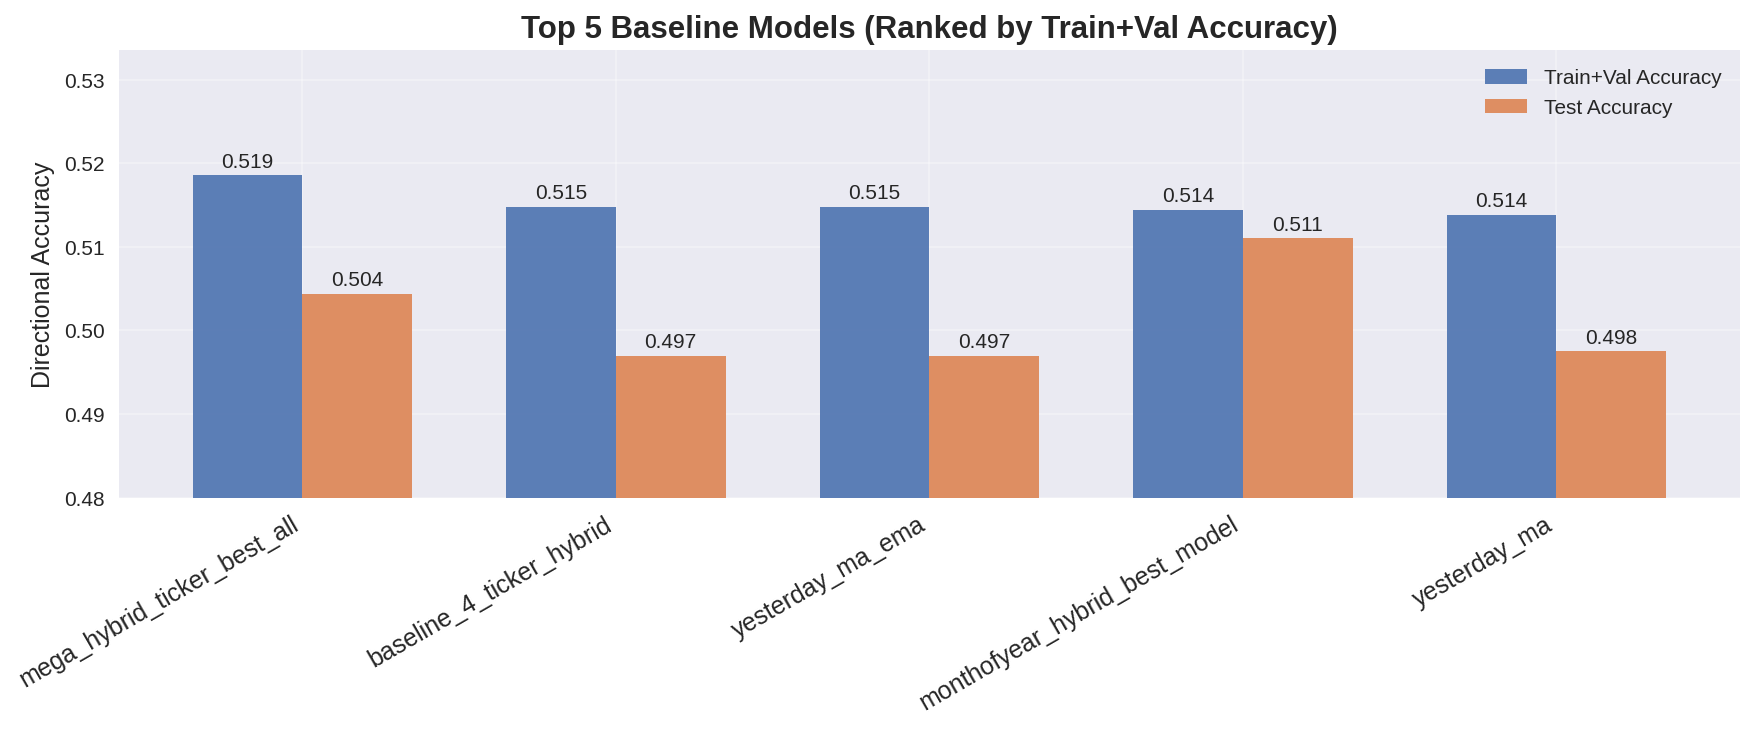

In [140]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Select top 5 by trainval accuracy
df_top5 = model_comparison_df.sort_values("trainval_acc", ascending=False).head(5).reset_index(drop=True)

models = df_top5["model"]
trainval = df_top5["trainval_acc"]
test = df_top5["test_acc"]

# X positions
x = np.arange(len(models))
width = 0.35

# Professional muted academic colors
train_color = "#4C72B0"   # muted blue
test_color = "#DD8452"    # muted orange

fig, ax = plt.subplots(figsize=(12, 5))

# Bars
bars_train = ax.bar(x - width/2, trainval, width, 
                    label='Train+Val Accuracy', 
                    color=train_color, alpha=0.9)

bars_test = ax.bar(x + width/2, test, width, 
                   label='Test Accuracy', 
                   color=test_color, alpha=0.9)

# Add value labels
for bar in bars_train:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.0005,
            f"{height:.3f}", ha='center', va='bottom', fontsize=10)

for bar in bars_test:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.0005,
            f"{height:.3f}", ha='center', va='bottom', fontsize=10)

# Labels & formatting
ax.set_ylabel("Directional Accuracy", fontsize=12)
ax.set_title("Top 5 Baseline Models (Ranked by Train+Val Accuracy)",
             fontsize=15, weight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12)

ax.set_ylim(0.48, df_top5["trainval_acc"].max() + 0.015)

ax.legend()

plt.tight_layout()
plt.savefig("../documents/figures/baseline_model_comparison_top5.pdf", dpi=300, bbox_inches="tight")
plt.show()
